In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)

In [200]:
df = pd.read_csv('EEG-Eye-State.csv')

In [201]:
df.head()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
0,4329.23,4393.85,4289.23,4280.51,4009.23,4635.90,4148.21,4211.28,4350.26,4238.46,4586.15,4222.05,4096.92,4641.03,0
1,4324.62,4384.10,4293.85,4279.49,4004.62,4632.82,4148.72,4207.69,4342.05,4226.67,4586.67,4210.77,4097.44,4638.97,0
2,4327.69,4389.23,4295.38,4282.05,4006.67,4628.72,4156.41,4206.67,4336.92,4222.05,4583.59,4207.69,4096.92,4630.26,0
3,4328.72,4396.41,4296.41,4287.69,4011.79,4632.31,4155.90,4210.77,4343.59,4235.38,4582.56,4217.44,4097.44,4630.77,0
4,4326.15,4398.46,4292.31,4288.21,4011.79,4632.82,4151.28,4212.82,4347.69,4244.10,4586.67,4210.77,4095.90,4627.69,0


In [202]:
df.tail()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
14975,4281.03,4340.51,4245.64,4269.23,3990.26,4593.33,4116.92,4171.28,4333.85,4221.54,4614.36,4203.08,4074.87,4625.64,1
14976,4276.92,4333.33,4245.13,4259.49,3991.79,4590.26,4110.77,4162.56,4332.82,4217.44,4615.38,4194.36,4073.33,4621.54,1
14977,4277.44,4339.49,4246.67,4257.95,3990.77,4591.79,4113.85,4160.51,4333.33,4212.82,4615.38,4193.33,4072.82,4623.59,1
14978,4284.62,4350.77,4251.28,4267.18,3991.79,4596.41,4122.05,4165.64,4334.36,4220.00,4616.41,4200.00,4080.51,4628.72,1
14979,4287.69,4350.77,4260.00,4274.36,3997.44,4597.95,4121.03,4167.69,4333.33,4226.67,4616.41,4212.31,4088.72,4638.46,1


In [203]:
df.shape

(14980, 15)

In [204]:
df.columns

Index(['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7',
       'P8', 'O1', 'O2', 'eyeDetection'],
      dtype='object')

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AF3           14980 non-null  float64
 1   AF4           14980 non-null  float64
 2   F3            14980 non-null  float64
 3   F4            14980 non-null  float64
 4   F7            14980 non-null  float64
 5   F8            14980 non-null  float64
 6   FC5           14980 non-null  float64
 7   FC6           14980 non-null  float64
 8   T7            14980 non-null  float64
 9   T8            14980 non-null  float64
 10  P7            14980 non-null  float64
 11  P8            14980 non-null  float64
 12  O1            14980 non-null  float64
 13  O2            14980 non-null  float64
 14  eyeDetection  14980 non-null  int64  
dtypes: float64(14), int64(1)
memory usage: 1.7 MB


In [206]:
df.describe()

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
count,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000,14980.000000
mean,4321.917777,4416.435832,4264.022433,4279.232774,4009.767694,4615.205336,4164.946326,4202.456900,4341.741075,4231.316200,4644.022379,4218.826610,4110.400160,4616.056904,0.448798
std,2492.072174,5891.285043,44.428052,41.544312,45.941672,1208.369958,5216.404632,37.785981,34.738821,38.050903,2924.789537,2136.408523,4600.926543,29.292603,0.497388
min,1030.770000,1366.150000,1040.000000,2257.950000,2830.770000,86.666700,2453.330000,3273.330000,2089.740000,1816.410000,2768.210000,1357.950000,2086.150000,4567.180000,0.000000
25%,4280.510000,4342.050000,4250.260000,4267.690000,3990.770000,4590.770000,4108.210000,4190.260000,4331.790000,4220.510000,4611.790000,4190.770000,4057.950000,4604.620000,0.000000
50%,4294.360000,4354.870000,4262.560000,4276.920000,4005.640000,4603.080000,4120.510000,4200.510000,4338.970000,4229.230000,4617.950000,4199.490000,4070.260000,4613.330000,0.000000
75%,4311.790000,4372.820000,4270.770000,4287.180000,4023.080000,4617.440000,4132.310000,4211.280000,4347.180000,4239.490000,4626.670000,4209.230000,4083.590000,4624.100000,1.000000
max,309231.000000,715897.000000,6880.510000,7002.560000,7804.620000,152308.000000,642564.000000,6823.080000,6474.360000,6674.360000,362564.000000,265641.000000,567179.000000,7264.100000,1.000000


In [207]:
df.nunique()

AF3             548
AF4             592
F3              345
F4              343
F7              452
F8              558
FC5             312
FC6             419
T7              285
T8              346
P7              330
P8              304
O1              290
O2              294
eyeDetection      2
dtype: int64

In [208]:
df.isnull().sum()

AF3             0
AF4             0
F3              0
F4              0
F7              0
F8              0
FC5             0
FC6             0
T7              0
T8              0
P7              0
P8              0
O1              0
O2              0
eyeDetection    0
dtype: int64

In [209]:
df.isnull().sum().sum()

0

In [210]:
df.duplicated().sum()

0

In [211]:
eeg_columns = ['AF3','AF4','F3','F4','F7','F8','FC5','FC6',
               'T7','T8','P7','P8','O1','O2']

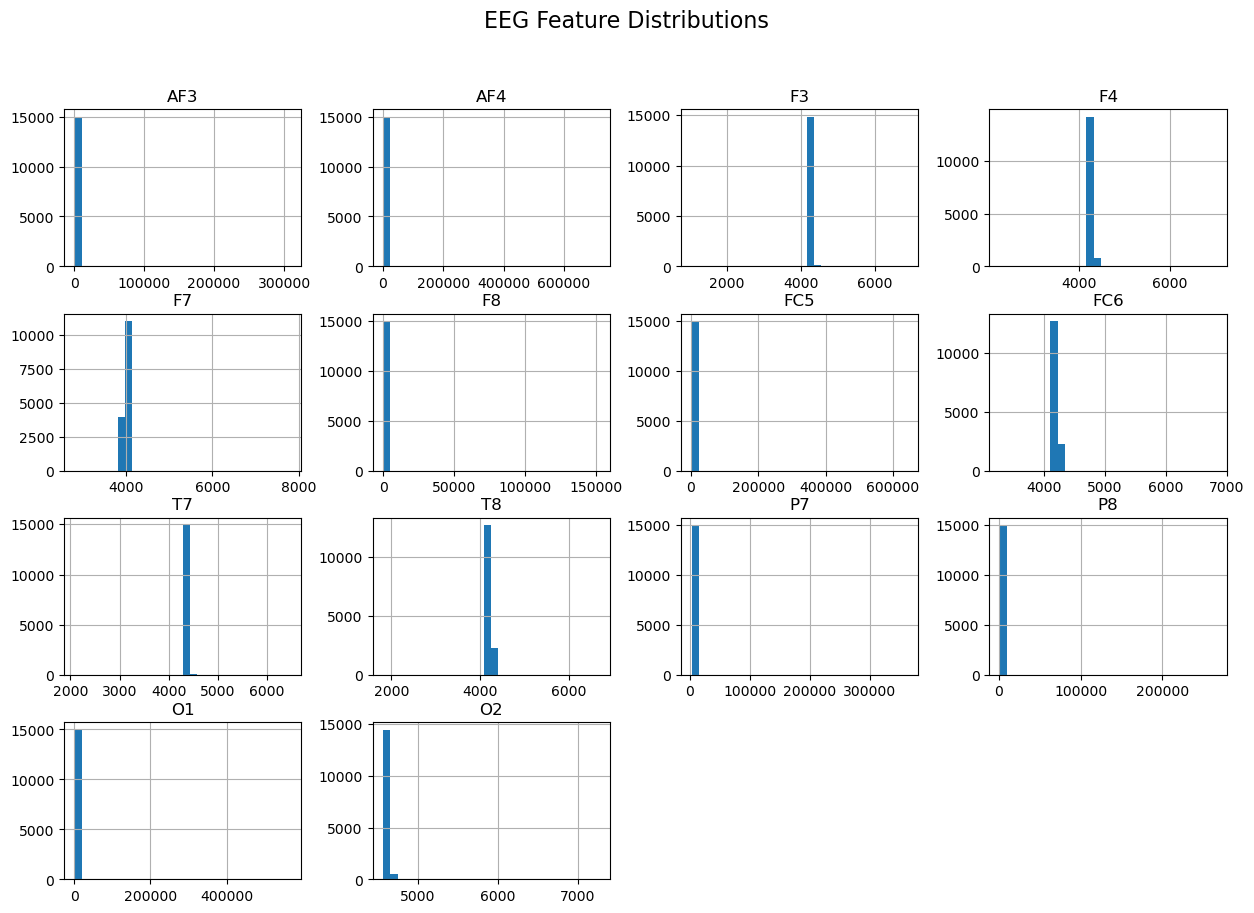

In [212]:
df[eeg_columns].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("EEG Feature Distributions", fontsize=16)
plt.show()

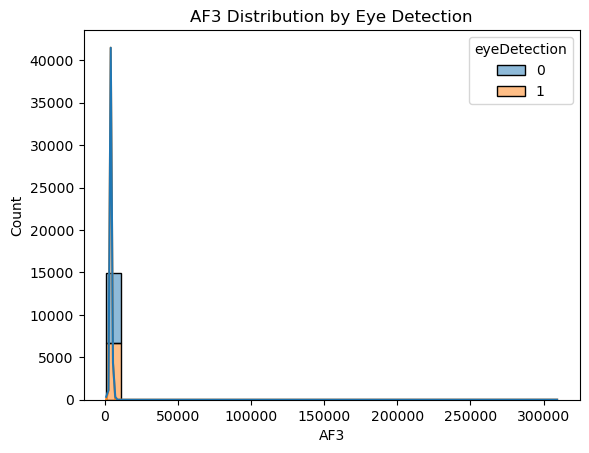

In [213]:
sns.histplot(
    data=df,
    x='AF3',
    hue='eyeDetection',
    bins=30,
    kde=True,
    multiple='stack'
)

plt.title("AF3 Distribution by Eye Detection")
plt.show()


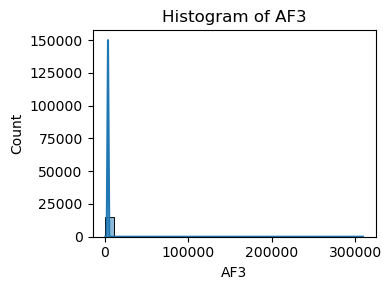

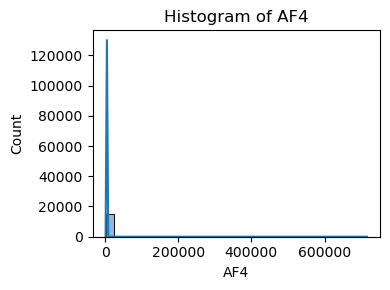

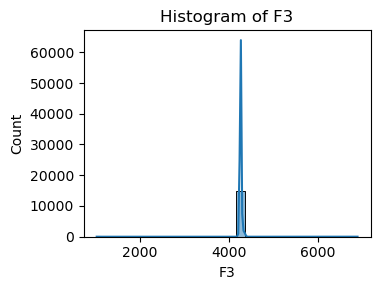

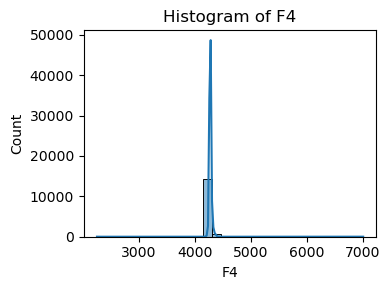

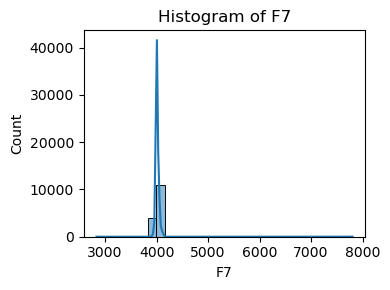

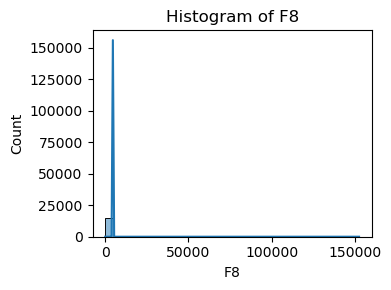

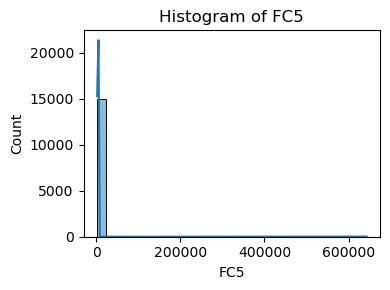

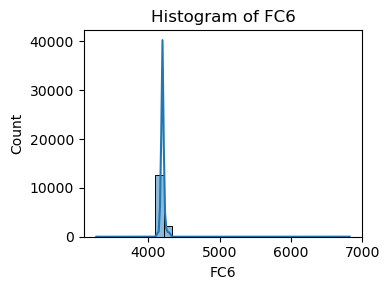

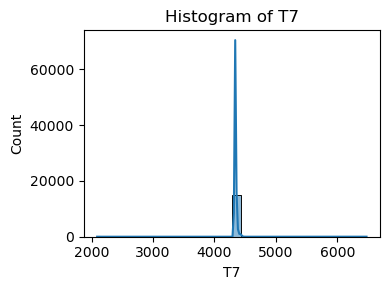

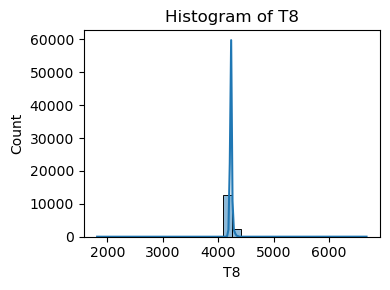

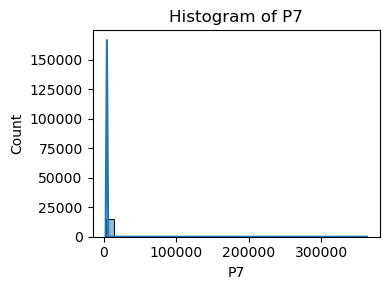

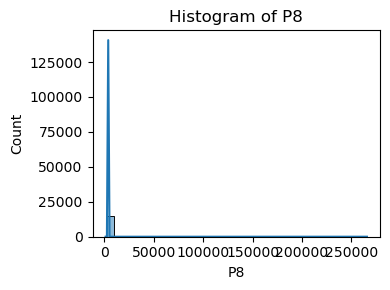

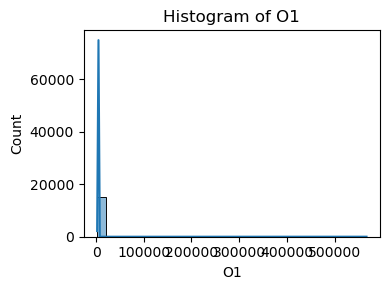

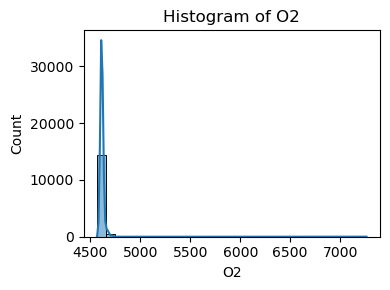

In [214]:
for col in eeg_columns:
    plt.figure(figsize=(4,3))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.tight_layout()
    plt.show()


In [215]:
corr = df.corr()
corr

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2,eyeDetection
AF3,1.000000,0.012070,0.474569,-0.394334,0.261146,0.998714,0.012173,0.572997,0.278938,-0.070801,0.007958,0.999607,0.006630,0.040539,0.010458
AF4,0.012070,1.000000,-0.637363,-0.146960,-0.071895,-0.028968,0.161155,-0.127763,0.478852,0.336282,0.988310,-0.008055,0.165730,0.224627,-0.007550
F3,0.474569,-0.637363,1.000000,0.116761,0.583317,0.500276,-0.330162,0.517950,-0.272186,0.191273,-0.596566,0.486506,-0.335514,0.221270,0.038902
F4,-0.394334,-0.146960,0.116761,1.000000,0.275977,-0.399400,0.515388,0.411682,-0.095902,0.132692,-0.229149,-0.385643,0.517621,0.577013,0.047965
F7,0.261146,-0.071895,0.583317,0.275977,1.000000,0.251327,-0.208922,0.317418,-0.250816,0.489010,-0.042288,0.264922,-0.210591,0.517816,-0.079994
F8,0.998714,-0.028968,0.500276,-0.399400,0.251327,1.000000,-0.005351,0.577408,0.267107,-0.082256,-0.030921,0.998849,-0.011080,0.020493,0.013120
FC5,0.012173,0.161155,-0.330162,0.515388,-0.208922,-0.005351,1.000000,0.420311,0.504616,-0.519498,0.009049,0.013228,0.999961,0.130482,-0.007531
FC6,0.572997,-0.127763,0.517950,0.411682,0.317418,0.577408,0.420311,1.000000,0.336173,0.038252,-0.196873,0.577472,0.417041,0.433333,0.064294
T7,0.278938,0.478852,-0.272186,-0.095902,-0.250816,0.267107,0.504616,0.336173,1.000000,-0.225508,0.409277,0.264913,0.504231,-0.030063,-0.000369
T8,-0.070801,0.336282,0.191273,0.132692,0.489010,-0.082256,-0.519498,0.038252,-0.225508,1.000000,0.420539,-0.074047,-0.515699,0.640387,0.047218


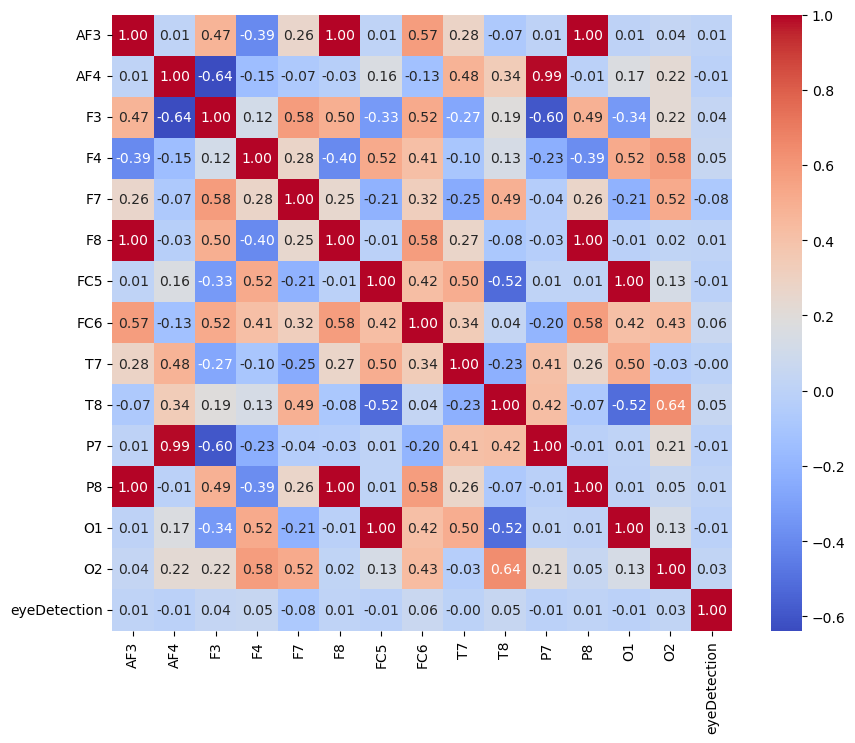

In [216]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,fmt='.2f',cmap='coolwarm',annot=True)
plt.show()

In [217]:
X = df.drop('eyeDetection',axis=1)
y = df['eyeDetection']

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [219]:
X_train

,AF3,AF4,F3,F4,F7,F8,FC5,FC6,T7,T8,P7,P8,O1,O2
1123,4301.03,4353.85,4259.49,4281.54,4018.46,4594.87,4126.15,4197.44,4347.18,4224.62,4577.44,4187.18,4083.59,4605.13
13517,4286.15,4349.74,4262.56,4271.28,4003.08,4606.67,4123.59,4205.13,4337.44,4223.59,4615.38,4197.95,4057.44,4607.69
12368,4290.77,4352.31,4255.38,4282.05,3983.59,4619.49,4117.44,4216.92,4341.54,4235.38,4628.72,4203.59,4077.95,4629.74
11320,4305.13,4374.87,4276.92,4278.46,4008.21,4612.82,4119.49,4209.74,4355.90,4221.54,4627.18,4180.00,4103.08,4607.18
9923,4296.92,4364.10,4272.31,4263.08,4012.82,4590.77,4105.64,4163.59,4332.31,4225.13,4618.97,4194.87,4053.33,4615.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9288,4289.74,4347.69,4244.10,4266.67,3993.33,4613.85,4122.05,4212.82,4345.13,4230.77,4622.56,4206.15,4055.38,4615.38
1485,4302.05,4375.38,4272.31,4288.72,4008.21,4609.23,4120.00,4214.87,4346.15,4233.85,4612.82,4199.49,4083.59,4611.79
11154,4317.44,4407.18,4283.59,4295.90,3981.03,4658.97,4121.03,4234.87,4351.28,4257.44,4635.38,4210.77,4091.28,4633.85
1006,4286.67,4339.49,4248.21,4273.85,4026.67,4586.67,4123.59,4196.92,4349.74,4221.54,4624.10,4196.92,4090.77,4601.03


In [220]:
y_train.value_counts()

eyeDetection
0    6606
1    5378
Name: count, dtype: int64

In [221]:
num_features = X.columns

In [222]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features)
    ]
)

In [223]:
preprocessor.set_output(transform='pandas')

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['AF3', 'AF4', 'F3', 'F4', 'F7', 'F8', 'FC5', 'FC6', 'T7', 'T8', 'P7',
       'P8', 'O1', 'O2'],
      dtype='object'))])

In [224]:
X_train_transform = preprocessor.fit_transform(X_train)
X_test_transform  = preprocessor.transform(X_test)

In [225]:
print(X_train_transform.shape)
print(X_test_transform.shape)


(11984, 14)
(2996, 14)


In [226]:
models = {
    "Logistic Regression": (
        LogisticRegression(max_iter=1000),
        {
            'model__C': [0.01, 0.1, 1, 10]
        }
    ),

    "SVM": (
        SVC(probability=True),
        {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf']
        }
    ),

    "KNN": (
        KNeighborsClassifier(),
        {
            'model__n_neighbors': [3,5,7,9],
            'model__weights': ['uniform', 'distance']
        }
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 5, 10]
        }
    )
}


In [227]:
results = []

for name, (model, params) in models.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(
        pipe,
        params,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:,1]

    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("="*60)
    print(f"MODEL: {name}")
    print("Best Params:", grid.best_params_)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

    results.append([name, f1, roc_auc])


MODEL: Logistic Regression
Best Params: {'model__C': 10}

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.76      0.67      1651
           1       0.57      0.39      0.46      1345

    accuracy                           0.59      2996
   macro avg       0.59      0.57      0.57      2996
weighted avg       0.59      0.59      0.58      2996

Confusion Matrix:
[[1259  392]
 [ 825  520]]
F1 Score: 0.460788657509969
ROC AUC: 0.6169562662259439
MODEL: SVM
Best Params: {'model__C': 10, 'model__kernel': 'rbf'}

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.89      0.80      1651
           1       0.81      0.57      0.67      1345

    accuracy                           0.75      2996
   macro avg       0.76      0.73      0.73      2996
weighted avg       0.76      0.75      0.74      2996

Confusion Matrix:
[[1474  177]
 [ 583  762]]
F1 Score: 0.6672504378283712
R

In [228]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'F1 Score', 'ROC AUC']
).sort_values(by='ROC AUC', ascending=False)

results_df


,Model,F1 Score,ROC AUC
3,Random Forest,0.925870,0.982422
2,KNN,0.900712,0.961992
1,SVM,0.667250,0.845498
0,Logistic Regression,0.460789,0.616956


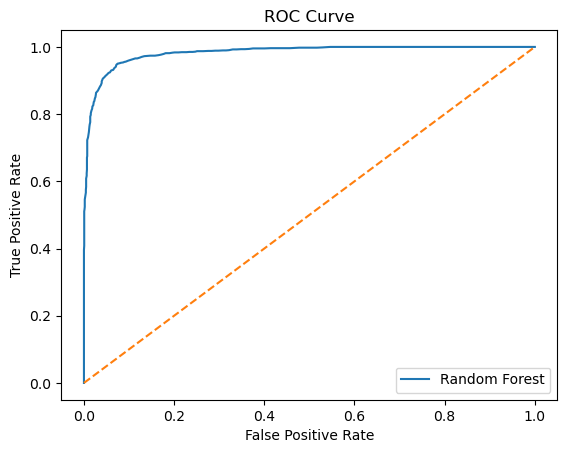

In [229]:
best_model_name = results_df.iloc[0]['Model']

best_pipe = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', models[best_model_name][0])
    ]),
    models[best_model_name][1],
    cv=5,
    scoring='f1'
)

best_pipe.fit(X_train, y_train)

y_prob = best_pipe.best_estimator_.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"{best_model_name}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()
